# Förutspå förväntat värde för hus baserat på givna faktorer

### Ladda in data som en Dataframe

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy  as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans

from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.dummy import DummyRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import (
    Ridge, 
    Lasso, 
    ElasticNet
    )

from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, IterativeImputer

df = pd.read_csv('housing.csv')

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Utforskar datan litegrann (EDA)

**Slutsats:** Det finns saknade värden i total_bedrooms

In [2]:
print("Antal kolumner och antal rader, samt dtypes och kolumn-namn:")
print(df.info())
print("\nAntal NaN värden per column:\n", df.isna().sum())
print("\nUndersöker vår target:\n",df["median_house_value"].describe())
print("\nAntal duplicerade rader:\n", df.duplicated().sum())

print("\nUndersöker vad vår string feature innehåller:\n",df["ocean_proximity"].value_counts(dropna=False))

Antal kolumner och antal rader, samt dtypes och kolumn-namn:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

Antal NaN värden per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households   

## Skapar en heatmap för att se hur våra numeriska variabler korrelerar med varann

#### Summering: En variabel sticker ut: median_income. Desto högre medianinkomsten är i området(?) desto högre värde på huset.

**Notering:** I och med att households, alltså antal personer i ett hushåll, korrelerar till 98% med total_bedrooms, så skulle man kunna använda datan i total_households för att fylla i total_bedrooms.

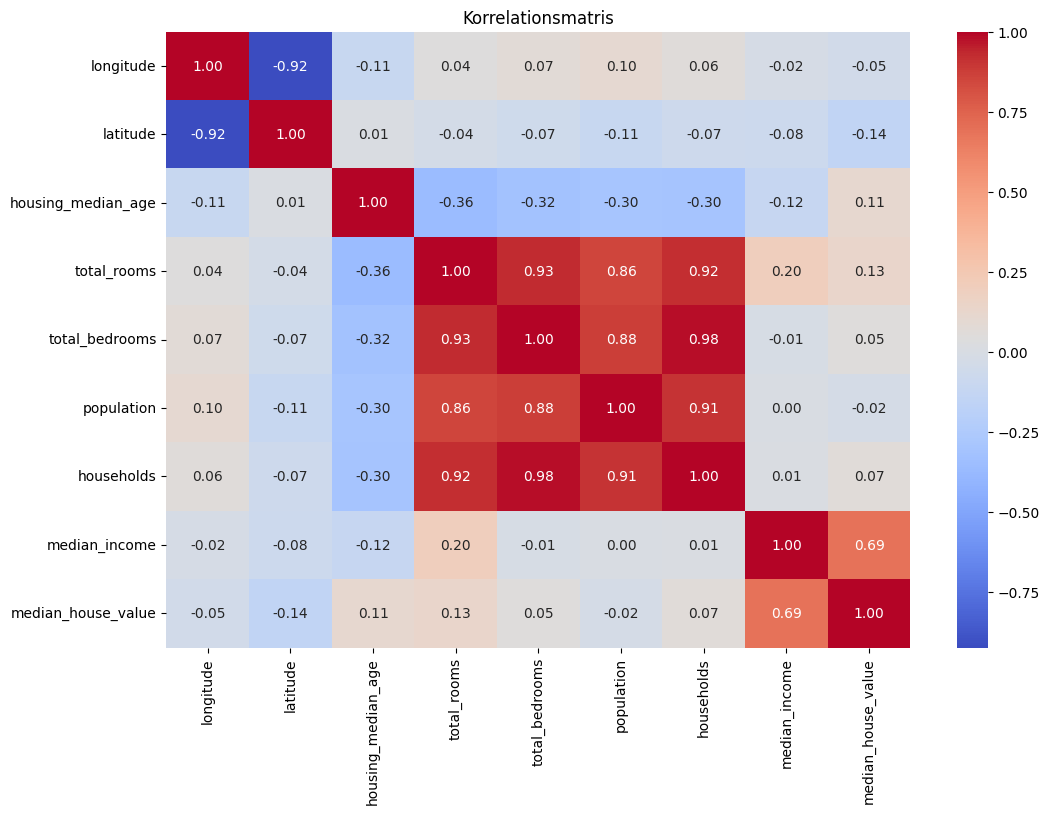

0     126.0
1    1138.0
2     177.0
3     219.0
4     259.0
Name: households, dtype: float64

In [3]:
plt.figure(figsize=(12,8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korrelationsmatris')
plt.show()

df["households"].head()

Scatterplot av median_income och median_house_value med regressionslinje. 

Här ser vi ett maxtak för median_house_value på 500 000.

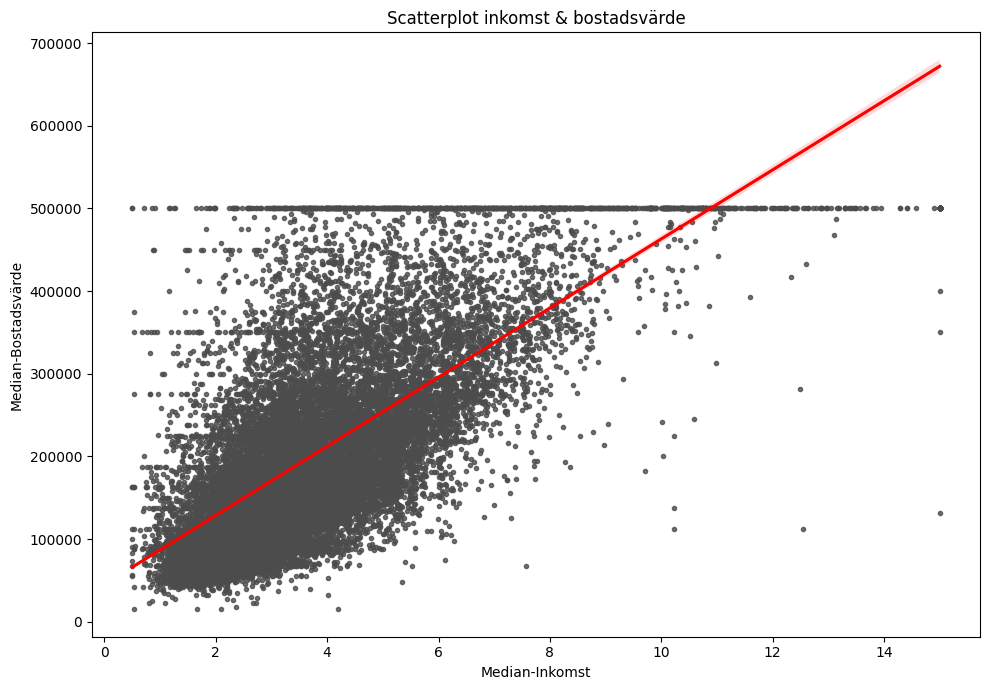

In [4]:
fig, ax = plt.subplots(figsize=(10,7))
sns.regplot(data=df, x="median_income", y="median_house_value", ax=ax, marker='.', color='.3', line_kws=dict(color='r'))
ax.set_title('Scatterplot inkomst & bostadsvärde')
ax.set_xlabel('Median-Inkomst')
ax.set_ylabel('Median-Bostadsvärde')

plt.tight_layout()
plt.show()


Splittar datan i train och test

In [ ]:
target = 'median_house_value'

X = df.drop(columns=[target])
y = df[target]

numerical_features = []
categorical_features = ['ocean_proximity']

for col in df.columns:
    if col != target and col != 'ocean_proximity':
        numerical_features.append(col)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(16512, 9) (4128, 9)


### Pipeline

Här väljer jag IterativeImputer istället för SimpleImputer som använder sig av medelvärdet, just för att IterativeImputer använder sig av datan från de andra variablerna för att fylla i de saknade total bedrooms. Anledningen till att jag gör detta är pga några av de övriga variablernas starka korrelation med total bedroom (se tidigare heatmap).

In [6]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

### Valda modeller och mina hyperparametrar

Mycket av det som är valt som hyperparametrar är taget ur andras verk, där jag senare kommer låta min gridsearch testa alla olika hyperparametrar för att se vilken hyperparameter som genererar bäst resultat för respektive modell, och därefter låta dessa bästa modeller möta varann.

Men varför just 3, 10, None på random forest? Jag låter trädet växa 3 steg (simpel modell), 10 steg (medel) och hur mycket som helst (överanpassad modell).

För de linjära modellerna fokuserade jag på parametern alpha för att styra regulariseringen. Jag använde en logaritmisk spridning (från 0.01 till 1000) för att effektivt söka av ett stort spann och hitta exakt hur mycket straff modellen behöver för att generalisera bra på okänd data.

In [7]:
# Random Forest
random_forest = Pipeline([
    ('preprocessing', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42))
])

param_grid_random_forest = {
    'random_forest__max_depth': [3, 10, None]
}

# Ridge
ridge = Pipeline([
    ('preprocessing', preprocessor),
    ('ridge', Ridge())
])

param_grid_ridge = {
    'ridge__alpha':[0.01, 0.1, 1.0, 10.0, 100.0]
}

# Lasso
lasso = Pipeline([
    ('preprocessing', preprocessor),
    ('lasso', Lasso(max_iter=100000, random_state=42))
])

param_grid_lasso = {
    'lasso__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
}

# ElasticNet
elastic = Pipeline([
    ('preprocessing', preprocessor),
    ('elastic', ElasticNet(alpha=0.5))
])

param_grid_elastic = {
    'elastic__alpha': [0.1, 0.5, 1.0, 10.0]
}

Bygger DummyRegressor och kör Cross Validation där jag använder mina hyperparametrar (mina params) för att testa vilken som ger bäst resultat

In [ ]:
# Skapar baseline
baseline = Pipeline([
    ('preprocessing', preprocessor),
    ('baseline', DummyRegressor())
])

# Tom baseline params för vår gridsearch, iom att den kräver någon form av params input
param_grid_baseline = {} 


# Valda modeller
chosen_models = {
    'baseline': baseline,
    'Random Forest': random_forest,
    'Lasso': lasso,
    'Ridge': ridge,
    'ElasticNet': elastic
}

# Params för valda modeller
param_grids = {
    'baseline': param_grid_baseline,
    'Random Forest': param_grid_random_forest,
    'Lasso': param_grid_lasso,
    'Ridge': param_grid_ridge,
    'ElasticNet': param_grid_elastic
}

# Bästa params med modell
best_models = {}

for name in chosen_models.keys():
    print(f'\nTestar modell: {name}...') 

    current_model = chosen_models[name]
    current_grid = param_grids[name]

    grid_search = GridSearchCV(
        estimator=current_model,
        param_grid=current_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search

    print('Vinnande parametrar:', grid_search.best_params_)
    print('Bästa CV-poäng (MSE):', -grid_search.best_score_)


resultat_dict = {namn: -grid.best_score_ for namn, grid in best_models.items()}

vinnare_namn = min(resultat_dict, key=resultat_dict.get)

print(f"Bästa modellen är {vinnare_namn} med MSE: {resultat_dict[vinnare_namn]}")


Testar modell: baseline...
Vinnande parametrar: {}
Bästa CV-poäng (MSE): 13369296823.892637

Testar modell: Random Forest...
Vinnande parametrar: {'random_forest__max_depth': None}
Bästa CV-poäng (MSE): 2427158865.458705

Testar modell: Lasso...
Vinnande parametrar: {'lasso__alpha': 0.1}
Bästa CV-poäng (MSE): 4711122146.50108

Testar modell: Ridge...
Vinnande parametrar: {'ridge__alpha': 1.0}
Bästa CV-poäng (MSE): 4711009532.56064

Testar modell: ElasticNet...
Vinnande parametrar: {'elastic__alpha': 0.1}
Bästa CV-poäng (MSE): 4812742621.40003
Bästa modellen är Random Forest med MSE: 2427158865.458705


### Random forest är vinnande med lägst MSE - Så nu låter vi den möta vår baseline, där vi tränar baseline på hela träningsdatan och kör sedan test datan för bägge modellerna för att se vad vi får för resultat

In [9]:
final_model = best_models[vinnare_namn].best_estimator_
final_baseline = best_models['baseline'].best_estimator_

y_pred_final_model = final_model.predict(X_test)
y_pred_final_baseline = final_baseline.predict(X_test)

rmse_final_model = np.sqrt(mean_squared_error(y_test, y_pred_final_model))
rmse_final_baseline = np.sqrt(mean_squared_error(y_test, y_pred_final_baseline))

mae_final_model = mean_absolute_error(y_test, y_pred_final_model)

print('Random Forest rmse-score: ', np.round(rmse_final_model, 1))
print('\nBaseline rmse-score: ', np.round(rmse_final_baseline, 1))
print('\nRandom Forest vinner med lägre rmse.\nMen hur mycket kan vi förvänta oss att modellen gissar fel med när det gäller faktiskta bostadspriset?\nFör detta beräknar vi Mean Absolute Error.')
print('\nRandom Forest mae-score: ', np.round(mae_final_model,1), 'dollar')

Random Forest rmse-score:  48850.8

Baseline rmse-score:  114485.6

Random Forest vinner med lägre rmse.
Men hur mycket kan vi förvänta oss att modellen gissar fel med när det gäller faktiskta bostadspriset?
För detta beräknar vi Mean Absolute Error.

Random Forest mae-score:  31579.1 dollar


Resultat: Vår Random Forest gissar generellt sätt fel med 31579 dollar. Är detta en bra eller dålig siffra? För att veta det så printar vi ut snittpriset för alla bostäderna i vårt dataset.

In [ ]:
print('Snittpriset för en bostad i vårt dataset: ',df['median_house_value'].mean(), ' dollar')
print('\nVår modell gissar i snitt fel med ', np.round(((np.round(mae_final_model,1) / df['median_house_value'].mean()) * 100), 1), '%')

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3144295813.py, line 2)

### KMeans: Hitta kluster i datan

Jag vill se om det går att finna några kluster för exempelvis "arbetarklassen", "medelklassen", "övre medelklassen" och "överklassen" i vår data, genom att använda Kmeans och säga åt den att skapa kluster med longitude, latitude och median income.

För att göra detta behöver jag först veta hur många kluster jag bör låta min KMeans leta efter. Därför kör vi elbow-metoden för att ta reda på hur

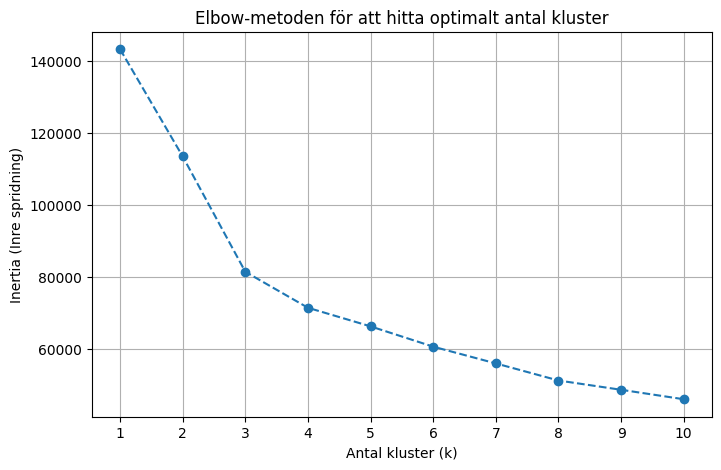

In [ ]:
inertia = []
K_range = range(1, 11) 

scaled_features = preprocessor.fit_transform(X_train)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_test.fit(scaled_features)
    inertia.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Antal kluster (k)')
plt.ylabel('Inertia (Inre spridning)')
plt.title('Elbow-metoden för att hitta optimalt antal kluster')
plt.xticks(K_range)
plt.grid(True)
plt.show()

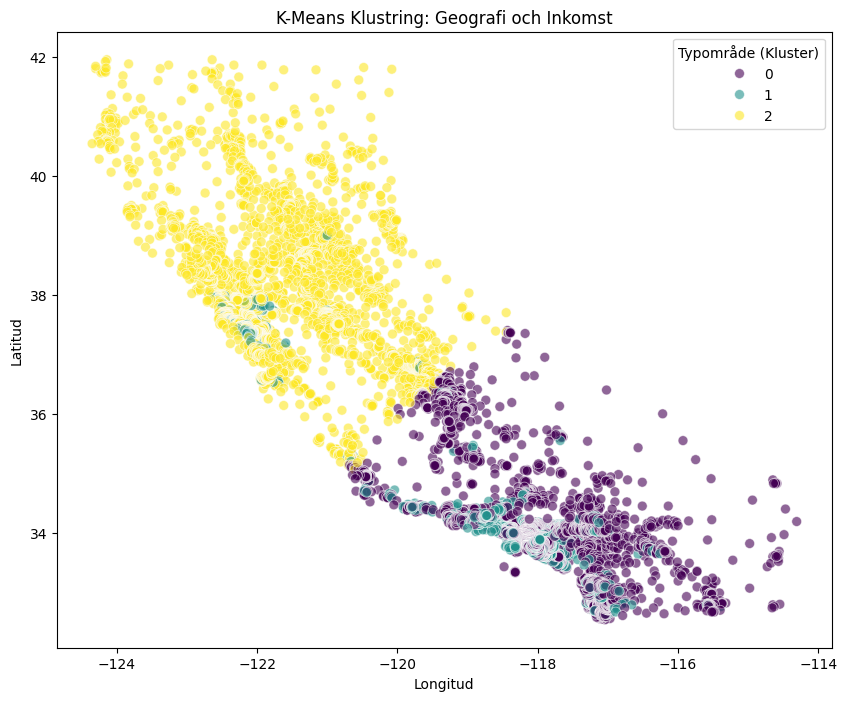

   Cluster  median_income  Verklig Inkomst (USD)
0        0       3.250999           32509.993674
1        1       7.440986           74409.861876
2        2       3.616261           36162.612062


In [ ]:
features_for_clustering = df[['longitude', 'latitude', 'median_income']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=50
)
plt.title('K-Means Klustring: Geografi och Inkomst')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Typområde (Kluster)')
plt.show()

inkomst_per_kluster = df.groupby('Cluster')['median_income'].mean().reset_index()
inkomst_per_kluster['Verklig Inkomst (USD)'] = inkomst_per_kluster['median_income'] * 10000

print(inkomst_per_kluster)